### **[Anomaly Detection with Isolation Forest](https://medium.com/@prathik.codes/1be7c5a69414)**

In [1]:
import sys

import warnings
warnings.filterwarnings("ignore")

IN_COLAB = "google.colab" in sys.modules

from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

np.random.seed(42)
np.set_printoptions(suppress=True, precision=4)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.precision", 4)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("fivethirtyeight")
plt.rc("figure", autolayout=True)
plt.rcParams['figure.figsize'] = (15, 10)

%autosave 15

Autosaving every 15 seconds


In [2]:
# generate tight cluster data
n_normal = 300
X_normal = 0.3 * np.random.randn(n_normal, 2)   # Centered near (0, 0)

# anomalies (scattered far from center)
n_anomalies = 20
X_anomalies = np.random.uniform(low=-4, high=4, size=(n_anomalies, 2))

# combine the data
X = np.vstack([X_normal, X_anomalies])
true_labels = np.array([1] * n_normal + [-1] * n_anomalies)  # 1=normal, -1=anomaly

display(pd.DataFrame(X, columns=["Feature 1", "Feature 2"]))

,Feature 1,Feature 2
0,0.1490,-0.0415
1,0.1943,0.4569
2,-0.0702,-0.0702
3,0.4738,0.2302
4,-0.1408,0.1628
5,-0.1390,-0.1397
6,0.0726,-0.5740
7,-0.5175,-0.1687
8,-0.3038,0.0943
9,-0.2724,-0.4237


In [3]:
# isolation forest
clf = IsolationForest(
  n_estimators=100,       # 100 isolation trees
  max_samples='auto',     # Use min(256, n_samples) per tree
  contamination=0.06,     # ~6% of the data is anomalous
  random_state=42
)

clf.fit(X)

IsolationForest(contamination=0.06, random_state=42)

In [4]:
# predictions : 1 = normal, -1 = anomaly
predictions = clf.predict(X)
anomaly_scores = clf.decision_function(X)   # Higher = more normal
raw_scores = clf.score_samples(X)           # Raw anomaly score (negated)

Classification Report:
              precision    recall  f1-score   support

     Anomaly       0.95      0.95      0.95        20
      Normal       1.00      1.00      1.00       300

    accuracy                           0.99       320
   macro avg       0.97      0.97      0.97       320
weighted avg       0.99      0.99      0.99       320

Confusion Matrix:


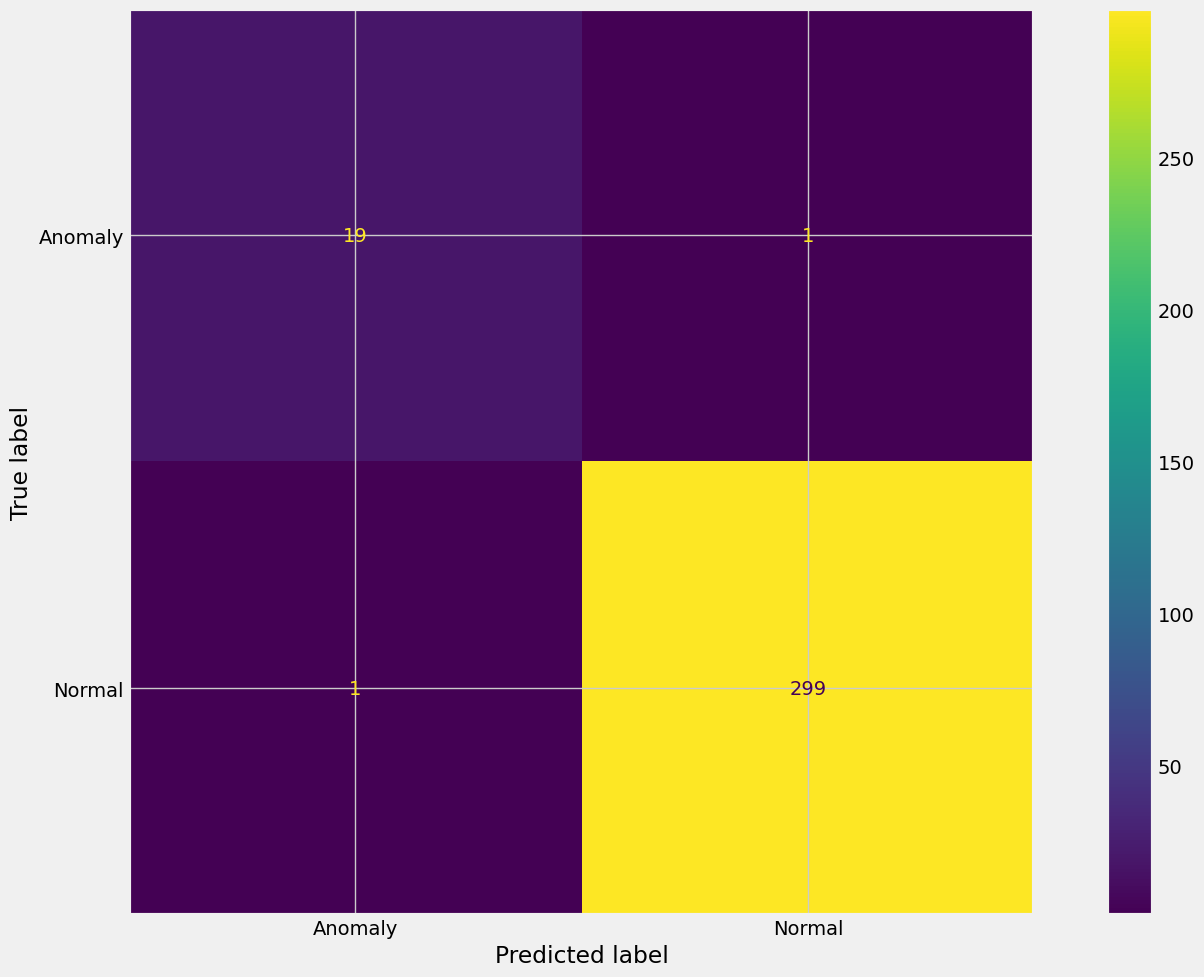

In [5]:
print("Classification Report:")
print(classification_report(true_labels, predictions, target_names=["Anomaly", "Normal"]))


print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(true_labels, predictions, display_labels=["Anomaly", "Normal"])
plt.show()

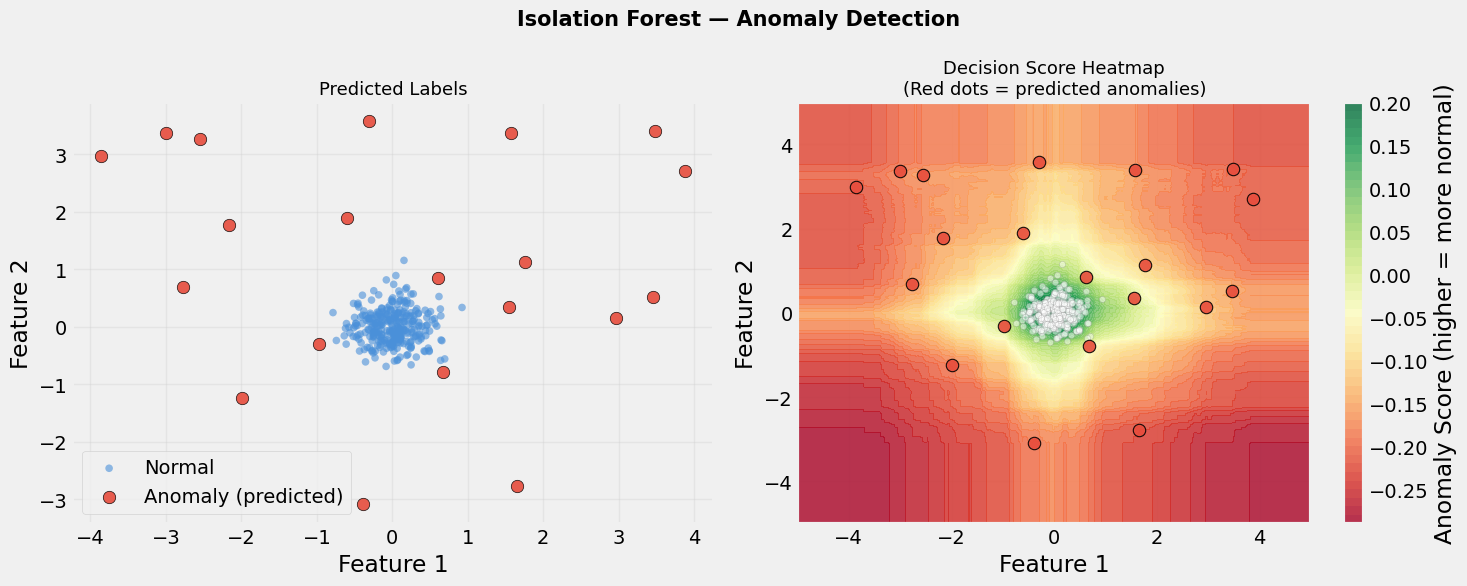

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Isolation Forest — Anomaly Detection", fontsize=15, fontweight="bold")

# Plot 1: Predictions
ax = axes[0]
normal_mask   = predictions == 1
anomaly_mask  = predictions == -1

ax.scatter(X[normal_mask, 0],  X[normal_mask, 1],
           c="#4A90D9", alpha=0.6, s=30, label="Normal", edgecolors="none")
ax.scatter(X[anomaly_mask, 0], X[anomaly_mask, 1],
           c="#E74C3C", alpha=0.9, s=80, label="Anomaly (predicted)",
           edgecolors="black", linewidths=0.5)

ax.set_title("Predicted Labels", fontsize=13)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Anomaly Score Heatmap
ax = axes[1]
xx, yy = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-5, 5, 300))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

heatmap = ax.contourf(xx, yy, Z, levels=50, cmap="RdYlGn", alpha=0.8)
plt.colorbar(heatmap, ax=ax, label="Anomaly Score (higher = more normal)")

ax.scatter(X[normal_mask, 0],  X[normal_mask, 1],
           c="white", alpha=0.5, s=20, edgecolors="gray", linewidths=0.3)
ax.scatter(X[anomaly_mask, 0], X[anomaly_mask, 1],
           c="#E74C3C", alpha=0.9, s=80, edgecolors="black", linewidths=0.8)

ax.set_title("Decision Score Heatmap\n(Red dots = predicted anomalies)", fontsize=13)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()